# 03 - Modelo de Red Neuronal con Keras

En este notebook se implementa una red neuronal tipo perceptrón multicapa utilizando Keras. Se utiliza el dataset ya preprocesado en el Notebook 02, evitando repetir el tratamiento de datos y garantizando el uso de un pipeline reutilizable.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
X_train_p = joblib.load('modelo_final/X_train_p.pkl')
X_val_p = joblib.load('modelo_final/X_val_p.pkl')
X_test_p = joblib.load('modelo_final/X_test_p.pkl')

y_train = joblib.load('modelo_final/y_train.pkl')
y_val = joblib.load('modelo_final/y_val.pkl')
y_test = joblib.load('modelo_final/y_test.pkl')

print("Train:", X_train_p.shape)
print("Validation:", X_val_p.shape)
print("Test:", X_test_p.shape)

Train: (5088, 49)
Validation: (898, 49)
Test: (1057, 49)


Los datos utilizados en este notebook corresponden a las matrices ya transformadas en el Notebook 02. Esto significa que los valores faltantes fueron imputados, las variables categóricas codificadas mediante OneHotEncoder, las variables numéricas escaladas y las particiones train, validation y test creadas previamente. Esta estrategia evita duplicación de código y reduce el riesgo de data leakage.

### Modelo Keras base


In [9]:
input_dim = X_train_p.shape[1]

base_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

base_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc')
    ]
)

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           3,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar modelo base


In [11]:
# la red neuronal aprende  
# cada epoca: revisa clientes, calcula error , ajusta pesos , mejora
early_stopping_base = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
)

history_base = base_model.fit(
    X_train_p,
    y_train,
    validation_data=(X_val_p, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_base],
    verbose=1
)  # SI DEJA DE MEJORAR ES PARA EVITAR OVERFFTING

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7816 - auc: 0.8096 - loss: 0.4529 - val_accuracy: 0.8051 - val_auc: 0.8354 - val_loss: 0.4290
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8021 - auc: 0.8461 - loss: 0.4159 - val_accuracy: 0.8140 - val_auc: 0.8378 - val_loss: 0.4258
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8033 - auc: 0.8497 - loss: 0.4116 - val_accuracy: 0.8107 - val_auc: 0.8380 - val_loss: 0.4250
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8046 - auc: 0.8520 - loss: 0.4088 - val_accuracy: 0.8118 - val_auc: 0.8371 - val_loss: 0.4254
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8060 - auc: 0.8544 - loss: 0.4059 - val_accuracy: 0.8107 - val_auc: 0.8365 - val_loss: 0.4255
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8084 - auc: 0.8564 - loss: 0.4034 - val_accuracy: 0.8096 - val_auc: 0.8365 - val_loss: 0.4258
Epoch 7/100
159/159 ━━━━━━━━━━━━━━

### Evaluación del modelo base

In [13]:
y_proba_base = base_model.predict(X_test_p).ravel()
y_pred_base = (y_proba_base >= 0.5).astype(int)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
roc_auc_base = roc_auc_score(y_test, y_proba_base)

print("="*50)
print("RESULTADOS MODELO KERAS BASE")
print("="*50)

print(f"Accuracy : {acc_base:.4f}")
print(f"F1-score : {f1_base:.4f}")
print(f"ROC-AUC  : {roc_auc_base:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_base))

cm_base = confusion_matrix(y_test, y_pred_base)
print("\nMatriz de confusión:")
print(cm_base)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RESULTADOS MODELO KERAS BASE
Accuracy : 0.8013
F1-score : 0.5946
ROC-AUC  : 0.8496

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       777
           1       0.65      0.55      0.59       280

    accuracy                           0.80      1057
   macro avg       0.75      0.72      0.73      1057
weighted avg       0.79      0.80      0.80      1057


Matriz de confusión:
[[693  84]
 [126 154]]


### GRAFICOS MODELO BASE KERAS


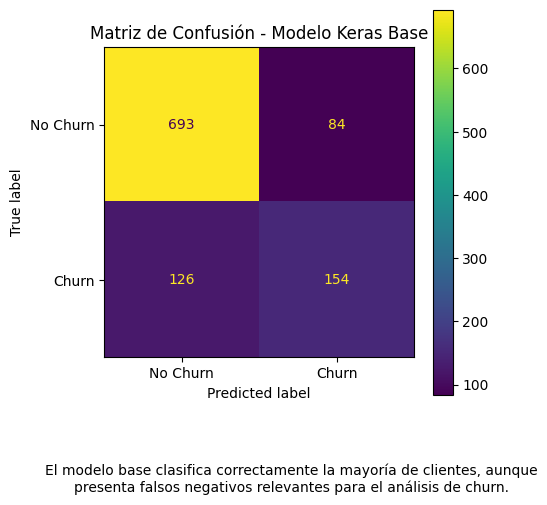

In [14]:
fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=['No Churn', 'Churn']
)

disp.plot(ax=ax)
plt.title('Matriz de Confusión - Modelo Keras Base')

plt.figtext(
    0.5,
    -0.08,
    "El modelo base clasifica correctamente la mayoría de clientes, aunque presenta falsos negativos relevantes para el análisis de churn.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

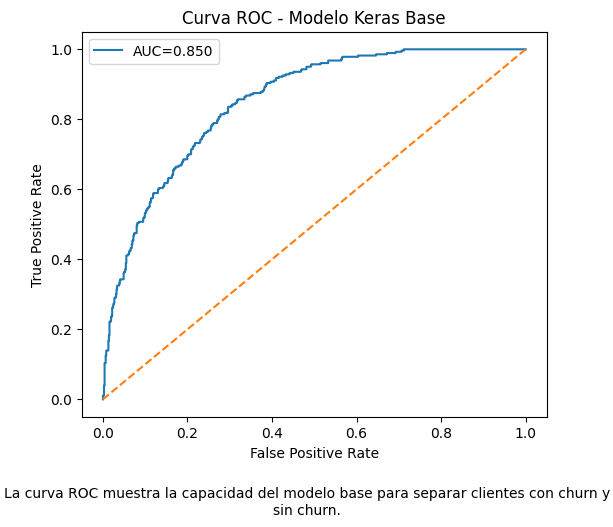

In [15]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)

plt.figure(figsize=(6,5))
plt.plot(fpr_base, tpr_base, label=f'AUC={roc_auc_base:.3f}')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo Keras Base')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "La curva ROC muestra la capacidad del modelo base para separar clientes con churn y sin churn.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()


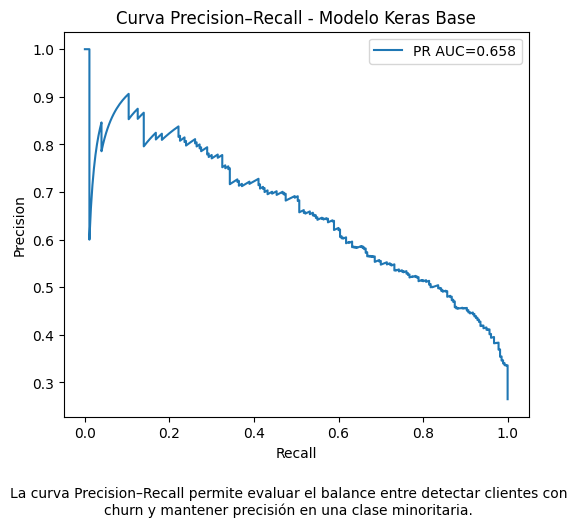

In [16]:
precision_base, recall_base, _ = precision_recall_curve(
    y_test,
    y_proba_base
)

pr_auc_base = auc(recall_base, precision_base)

plt.figure(figsize=(6,5))
plt.plot(
    recall_base,
    precision_base,
    label=f'PR AUC={pr_auc_base:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision–Recall - Modelo Keras Base')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "La curva Precision–Recall permite evaluar el balance entre detectar clientes con churn y mantener precisión en una clase minoritaria.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

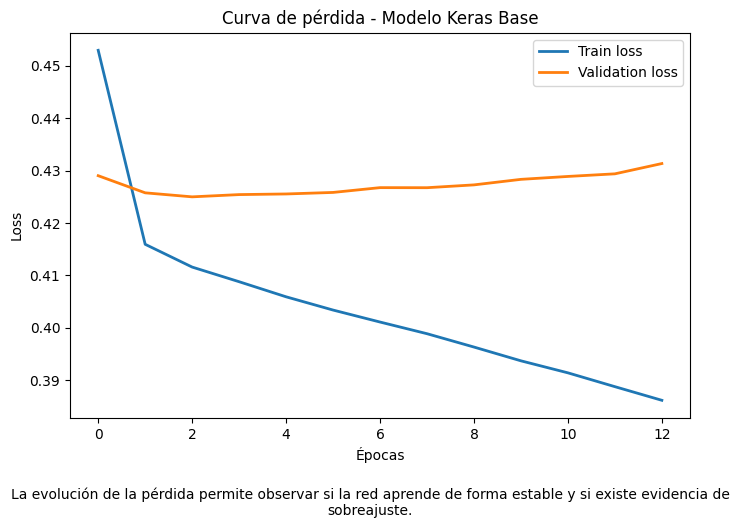

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_base.history['loss'], label='Train loss', linewidth=2)
plt.plot(history_base.history['val_loss'], label='Validation loss', linewidth=2)

plt.title('Curva de pérdida - Modelo Keras Base')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "La evolución de la pérdida permite observar si la red aprende de forma estable y si existe evidencia de sobreajuste.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

# Tuning del modelo Keras



Se evaluaron distintas configuraciones de la red neuronal con el objetivo de mejorar el desempeño del modelo. El tuning incluyó variaciones en número de neuronas, función de activación, learning rate, optimizador, regularización L2, dropout, batch size, número de épocas y early stopping.

In [19]:
# Tunnig de Hiperparametros, funcion para construir modelos
def build_model(
    input_dim,
    neurons_1=64,
    neurons_2=32,
    activation='relu',
    learning_rate=0.001,
    optimizer_name='adam',
    l2_value=0.001,
    dropout_rate=0.2
):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(
            neurons_1,
            activation=activation,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.Dropout(dropout_rate),
        layers.Dense(
            neurons_2,
            activation=activation,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])

    if optimizer_name == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc')
        ]
    )

    return model

In [20]:
#busqueda manual

param_grid = [
    {
        'neurons_1': 64,
        'neurons_2': 32,
        'activation': 'relu',
        'learning_rate': 0.001,
        'optimizer_name': 'adam',
        'l2_value': 0.001,
        'dropout_rate': 0.2,
        'batch_size': 32
    },
    {
        'neurons_1': 128,
        'neurons_2': 64,
        'activation': 'relu',
        'learning_rate': 0.001,
        'optimizer_name': 'adam',
        'l2_value': 0.001,
        'dropout_rate': 0.3,
        'batch_size': 32
    },
    {
        'neurons_1': 128,
        'neurons_2': 64,
        'activation': 'relu',
        'learning_rate': 0.0005,
        'optimizer_name': 'adam',
        'l2_value': 0.0005,
        'dropout_rate': 0.3,
        'batch_size': 16
    },
    {
        'neurons_1': 64,
        'neurons_2': 32,
        'activation': 'tanh',
        'learning_rate': 0.001,
        'optimizer_name': 'rmsprop',
        'l2_value': 0.001,
        'dropout_rate': 0.2,
        'batch_size': 32
    }
]

results = []

for i, params in enumerate(param_grid, start=1):
    print(f"\nEntrenando configuración {i}")
    print(params)

    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    temp_model = build_model(
        input_dim=input_dim,
        neurons_1=params['neurons_1'],
        neurons_2=params['neurons_2'],
        activation=params['activation'],
        learning_rate=params['learning_rate'],
        optimizer_name=params['optimizer_name'],
        l2_value=params['l2_value'],
        dropout_rate=params['dropout_rate']
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=8,
        mode='max',
        restore_best_weights=True
    )

    history_temp = temp_model.fit(
        X_train_p,
        y_train,
        validation_data=(X_val_p, y_val),
        epochs=80,
        batch_size=params['batch_size'],
        callbacks=[early_stopping],
        verbose=0
    )

    val_proba = temp_model.predict(X_val_p).ravel()
    val_pred = (val_proba >= 0.5).astype(int)

    results.append({
        **params,
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_f1': f1_score(y_val, val_pred),
        'val_auc': roc_auc_score(y_val, val_proba),
        'epochs_trained': len(history_temp.history['loss'])
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by='val_auc', ascending=False)


Entrenando configuración 1
{'neurons_1': 64, 'neurons_2': 32, 'activation': 'relu', 'learning_rate': 0.001, 'optimizer_name': 'adam', 'l2_value': 0.001, 'dropout_rate': 0.2, 'batch_size': 32}

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Entrenando configuración 2
{'neurons_1': 128, 'neurons_2': 64, 'activation': 'relu', 'learning_rate': 0.001, 'optimizer_name': 'adam', 'l2_value': 0.001, 'dropout_rate': 0.3, 'batch_size': 32}
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Entrenando configuración 3
{'neurons_1': 128, 'neurons_2': 64, 'activation': 'relu', 'learning_rate': 0.0005, 'optimizer_name': 'adam', 'l2_value': 0.0005, 'dropout_rate': 0.3, 'batch_size': 16}
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Entrenando configuración 4
{'neurons_1': 64, 'neurons_2': 32, 'activation': 'tanh', 'learning_rate': 0.001, 'optimizer_name': 'rmsprop', 'l2_value': 0.001, 'dropout_rate': 0.2, 'batch_size': 32}
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,neurons_1,neurons_2,activation,learning_rate,optimizer_name,l2_value,dropout_rate,batch_size,val_accuracy,val_f1,val_auc,epochs_trained
2,128,64,relu,0.0005,adam,0.0005,0.3,16,0.816258,0.606205,0.841444,15
0,64,32,relu,0.0010,adam,0.0010,0.2,32,0.811804,0.596659,0.840285,11
1,128,64,relu,0.0010,adam,0.0010,0.3,32,0.817372,0.598039,0.839687,27
3,64,32,tanh,0.0010,rmsprop,0.0010,0.2,32,0.812918,0.601896,0.837688,14


### Mejor configuración


In [22]:
best_params = results_df.sort_values(
    by='val_auc',
    ascending=False
).iloc[0].to_dict()

best_params

{'neurons_1': 128,
 'neurons_2': 64,
 'activation': 'relu',
 'learning_rate': 0.0005,
 'optimizer_name': 'adam',
 'l2_value': 0.0005,
 'dropout_rate': 0.3,
 'batch_size': 16,
 'val_accuracy': 0.8162583518930958,
 'val_f1': 0.6062052505966588,
 'val_auc': 0.8414438502673798,
 'epochs_trained': 15}

La configuración final fue seleccionada con base en el mayor ROC-AUC obtenido en el conjunto de validación. Esta métrica fue priorizada porque permite evaluar la capacidad del modelo para separar clientes con churn y sin churn, independientemente del umbral de clasificación.

### ENTRENAMIENTO DEL MODELO FINAL KERAS


In [26]:
tf.keras.backend.clear_session()
np.random.seed(SEED)
tf.random.set_seed(SEED)

final_model = build_model(
    input_dim=input_dim,
    neurons_1=int(best_params['neurons_1']),
    neurons_2=int(best_params['neurons_2']),
    activation=best_params['activation'],
    learning_rate=best_params['learning_rate'],
    optimizer_name=best_params['optimizer_name'],
    l2_value=best_params['l2_value'],
    dropout_rate=best_params['dropout_rate']
)

early_stopping_final = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
)

history_final = final_model.fit(
    X_train_p,
    y_train,
    validation_data=(X_val_p, y_val),
    epochs=100,
    batch_size=int(best_params['batch_size']),
    callbacks=[early_stopping_final],
    verbose=1
)

Epoch 1/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7575 - auc: 0.7837 - loss: 0.5518 - val_accuracy: 0.8073 - val_auc: 0.8342 - val_loss: 0.5018
Epoch 2/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7887 - auc: 0.8347 - loss: 0.4964 - val_accuracy: 0.8073 - val_auc: 0.8376 - val_loss: 0.4911
Epoch 3/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7999 - auc: 0.8394 - loss: 0.4860 - val_accuracy: 0.8085 - val_auc: 0.8382 - val_loss: 0.4854
Epoch 4/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7997 - auc: 0.8419 - loss: 0.4789 - val_accuracy: 0.8129 - val_auc: 0.8398 - val_loss: 0.4801
Epoch 5/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8027 - auc: 0.8468 - loss: 0.4695 - val_accuracy: 0.8129 - val_auc: 0.8402 - val_loss: 0.4745
Epoch 6/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8054 - auc: 0.8461 - loss: 0.4665 - val_accuracy: 0.8107 - val_auc: 0.8393 - val_loss: 0.4730
Epoch 7/100
318/318 ━━━━━━━━━━━━━━

### EVALUACION DEL MODELO FINAL KERAS


In [27]:
# EVALUACION DEL MODELO FINAL 
y_proba_final = final_model.predict(X_test_p).ravel()
y_pred_final = (y_proba_final >= 0.5).astype(int)

acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_proba_final)

print("="*50)
print("RESULTADOS MODELO KERAS FINAL")
print("="*50)

print(f"Accuracy : {acc_final:.4f}")
print(f"F1-score : {f1_final:.4f}")
print(f"ROC-AUC  : {roc_auc_final:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)
print("\nMatriz de confusión:")
print(cm_final)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RESULTADOS MODELO KERAS FINAL
Accuracy : 0.8023
F1-score : 0.5957
ROC-AUC  : 0.8523

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       777
           1       0.65      0.55      0.60       280

    accuracy                           0.80      1057
   macro avg       0.75      0.72      0.73      1057
weighted avg       0.79      0.80      0.80      1057


Matriz de confusión:
[[694  83]
 [126 154]]


### Comparación base vs final



In [28]:
# COMPARACION DE MODELOS
comparison_keras = pd.DataFrame({
    'Modelo': ['Keras Base', 'Keras Final con Tuning'],
    'Accuracy': [acc_base, acc_final],
    'F1-score': [f1_base, f1_final],
    'ROC-AUC': [roc_auc_base, roc_auc_final],
    'PR-AUC': [pr_auc_base, None]
})

comparison_keras

,Modelo,Accuracy,F1-score,ROC-AUC,PR-AUC
0,Keras Base,0.801325,0.594595,0.849616,0.658079
1,Keras Final con Tuning,0.802271,0.595745,0.852333,NaN


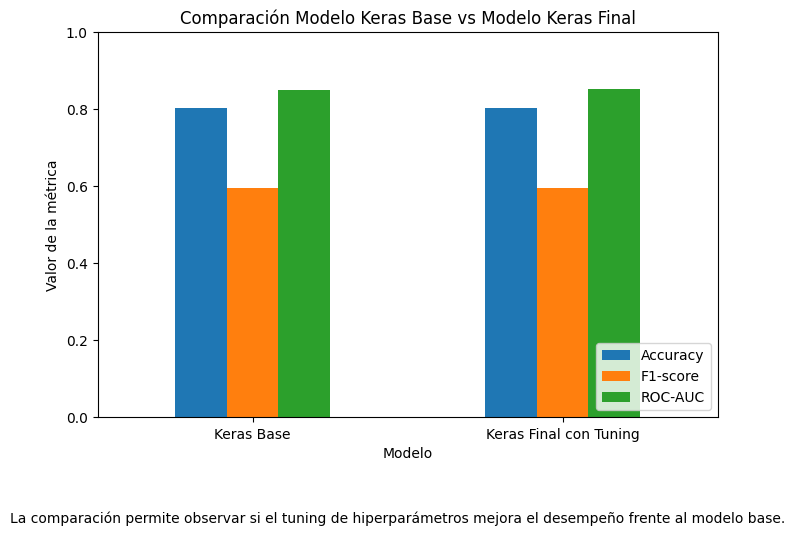

In [29]:
# GRAFICA PARA COMPARAR LOS MODELOS

comparison_keras.set_index('Modelo')[['Accuracy', 'F1-score', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Comparación Modelo Keras Base vs Modelo Keras Final')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.figtext(
    0.5,
    -0.10,
    "La comparación permite observar si el tuning de hiperparámetros mejora el desempeño frente al modelo base.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

### GRAFICOS DEL MODELO KERAS FINAL CON TUNNIG


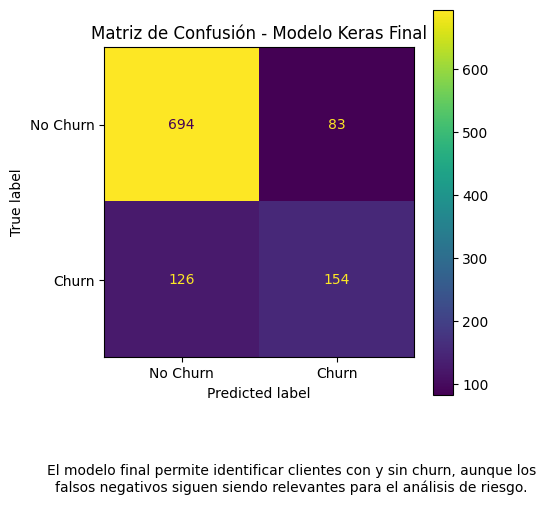

In [30]:
fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=['No Churn', 'Churn']
)

disp.plot(ax=ax)
plt.title('Matriz de Confusión - Modelo Keras Final')

plt.figtext(
    0.5,
    -0.08,
    "El modelo final permite identificar clientes con y sin churn, aunque los falsos negativos siguen siendo relevantes para el análisis de riesgo.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

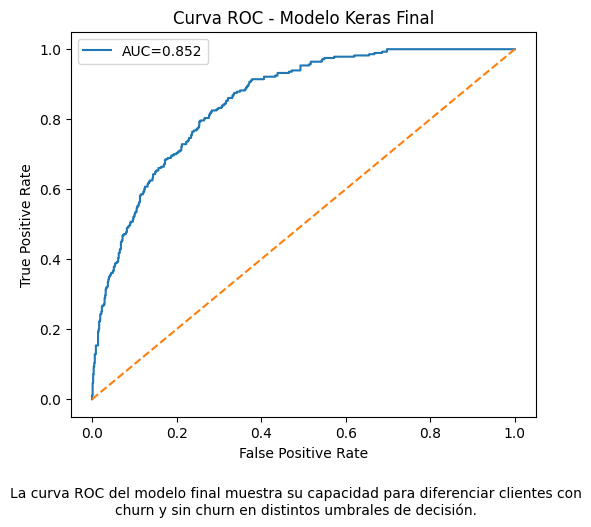

In [31]:
fpr_final, tpr_final, _ = roc_curve(y_test, y_proba_final)

plt.figure(figsize=(6,5))
plt.plot(
    fpr_final,
    tpr_final,
    label=f'AUC={roc_auc_final:.3f}'
)
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo Keras Final')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "La curva ROC del modelo final muestra su capacidad para diferenciar clientes con churn y sin churn en distintos umbrales de decisión.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

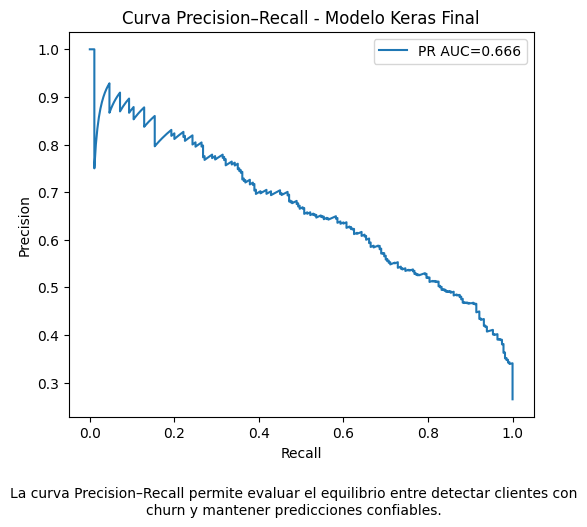

In [32]:
precision_final, recall_final, _ = precision_recall_curve(
    y_test,
    y_proba_final
)

pr_auc_final = auc(recall_final, precision_final)

plt.figure(figsize=(6,5))
plt.plot(
    recall_final,
    precision_final,
    label=f'PR AUC={pr_auc_final:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision–Recall - Modelo Keras Final')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "La curva Precision–Recall permite evaluar el equilibrio entre detectar clientes con churn y mantener predicciones confiables.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

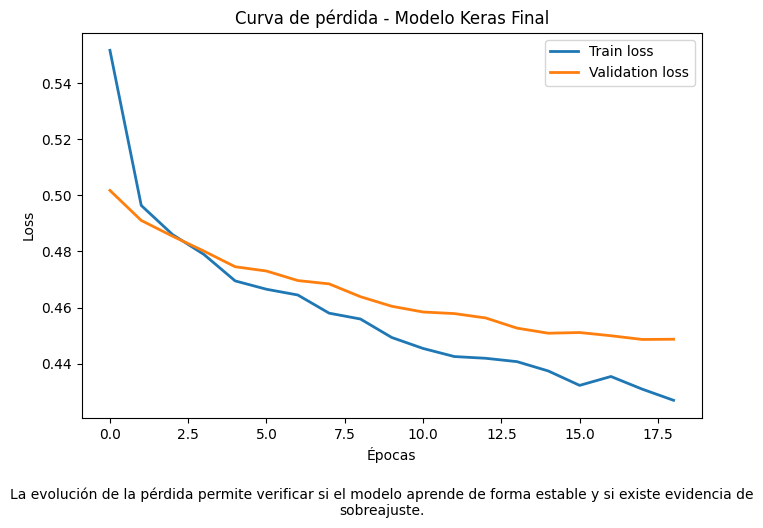

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    history_final.history['loss'],
    label='Train loss',
    linewidth=2
)

plt.plot(
    history_final.history['val_loss'],
    label='Validation loss',
    linewidth=2
)

plt.title('Curva de pérdida - Modelo Keras Final')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "La evolución de la pérdida permite verificar si el modelo aprende de forma estable y si existe evidencia de sobreajuste.",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

In [35]:
# PARA GUARDAR MODELO KERAS FINAL
import os

os.makedirs('modelo_final', exist_ok=True)

final_model.save('modelo_final/modelo_keras_final.keras')

print("Modelo Keras final guardado correctamente.")

Modelo Keras final guardado correctamente.


# Conclusión del modelo Keras

El modelo Keras base permitió establecer una primera referencia de desempeño para la predicción de churn. Posteriormente, mediante tuning de hiperparámetros se evaluaron distintas configuraciones de arquitectura, función de activación, learning rate, optimizador, regularización L2, dropout, batch size, número de épocas y early stopping.

El modelo final fue seleccionado según el mejor ROC-AUC en validación. Los resultados muestran que la red neuronal logra capturar patrones relevantes asociados al abandono de clientes, principalmente relacionados con antigüedad, tipo de contrato, método de pago, cargos y servicios contratados.